In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv


In [18]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [19]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [20]:
df = df.iloc[:,:2]
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
#renaming columns
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
print(df.shape)
df.info()

(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [23]:
df.label.value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

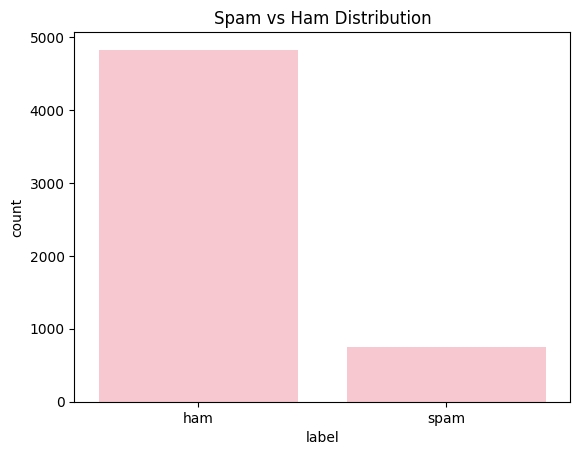

In [24]:
# spam vs ham distribution
sns.countplot(
    x='label',
    data=df,
    color='pink'
)

plt.title("Spam vs Ham Distribution")
plt.show()

In [25]:
print(df.isnull().sum())

duplicate = df.duplicated().sum()
print("dupliacate=",duplicate )


label      0
message    0
dtype: int64
dupliacate= 403


In [26]:
df.drop_duplicates(inplace=True)
print(df.shape)
print(df.info())
df.head()

(5169, 2)
<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5169 non-null   object
 1   message  5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB
None


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## **EDA**

In [27]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

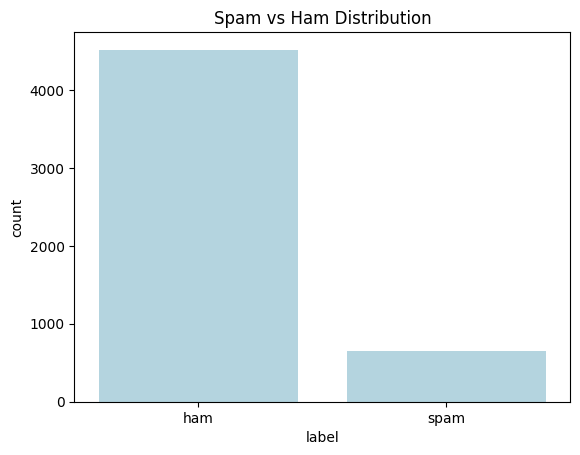

In [28]:
sns.countplot(
    x=df['label'],color='lightblue'
)

plt.title("Spam vs Ham Distribution")
plt.show()

#### shows that this is an unbalanced dataset. With ham as majority class and spam as minority class


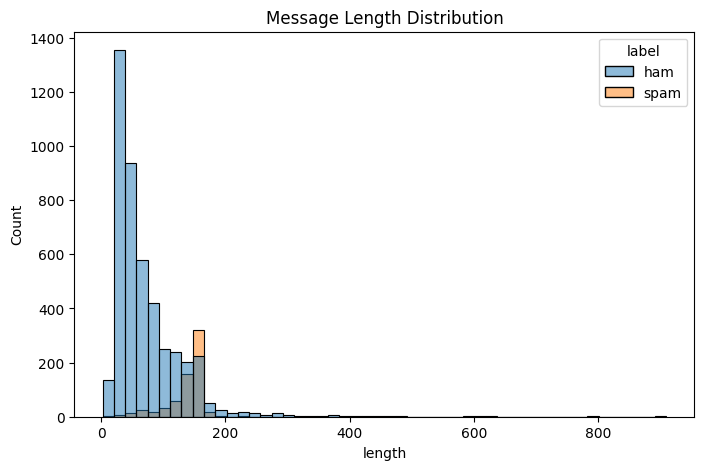

In [29]:
#message length -- as spam messages are usually longer
df['length'] = df['message'].apply(len)
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='length',
    hue='label',
    bins=50
)

plt.title("Message Length Distribution")
plt.show()

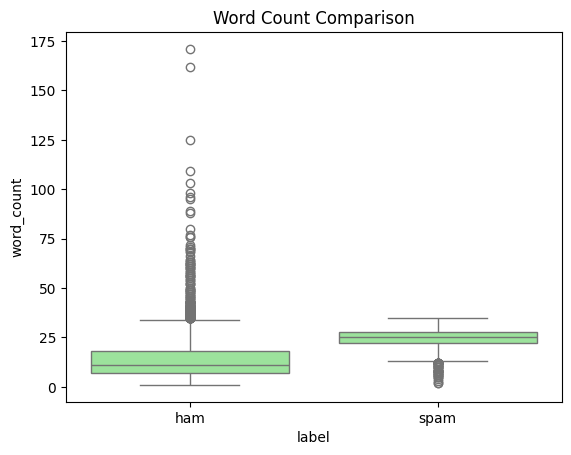

In [30]:
#word count analysis

df['word_count'] = df['message'].apply(
    lambda x: len(x.split())
)

sns.boxplot(
    x='label',
    y='word_count',
    data=df,
    color='lightgreen'
)

plt.title("Word Count Comparison")
plt.show()


In [31]:
#finding most common words in spams

#converting labels -- ham=0, spam=1
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

from collections import Counter

spam_words = " ".join(
    df[df['label']==1]['message']
)

words = spam_words.split()

common_words = Counter(words).most_common(20)

common_words



[('to', 522),
 ('a', 314),
 ('your', 171),
 ('call', 163),
 ('the', 160),
 ('or', 155),
 ('for', 152),
 ('2', 151),
 ('you', 150),
 ('is', 130),
 ('Call', 116),
 ('on', 112),
 ('have', 110),
 ('from', 109),
 ('and', 102),
 ('&', 89),
 ('with', 86),
 ('ur', 86),
 ('of', 79),
 ('FREE', 75)]

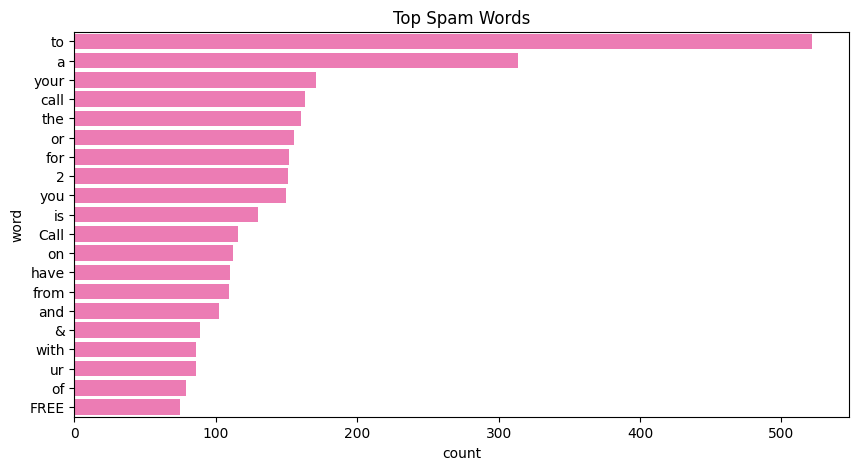

In [32]:
words_df = pd.DataFrame(
    common_words,
    columns=['word','count']
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=words_df,
    x='count',
    y='word',
    color='hotpink'
)

plt.title("Top Spam Words")

plt.show()

### **Text Preprocessing**
##### Preprocessing is done by stemming, removing stopwords, and tokenizing the text

In [33]:
import string

stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))


def clean_text(text):

    # lowercase
    text=text.lower()

    # remove special characters
    text=re.sub(
        '[^a-zA-Z]',
        ' ',
        text
    )

    # tokenize
    words=text.split()

    # remove stopwords + stemming
    words=[
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [34]:
df['clean_message'] = df['message'].apply(clean_text)
df.head()

,label,message,length,word_count,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",111,20,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,11,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,nah think goe usf live around though


## **Machine Learning**

In [35]:
#separating predictor and target variables
X = df['clean_message']
y = df['label']

#train-test split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
#TF_IDF vectorization
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [37]:
#Training a naive bayes model -- Multinomial Naive Bayes

model = MultinomialNB()

model.fit(
    X_train_tfidf,
    y_train
)


MultinomialNB()

In [38]:
#making predictions
y_pred = model.predict(
    X_test_tfidf
)

In [39]:
#Evaluation metrics
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.9700193423597679
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.99      0.79      0.88       145

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.93      1034
weighted avg       0.97      0.97      0.97      1034

[[888   1]
 [ 30 115]]


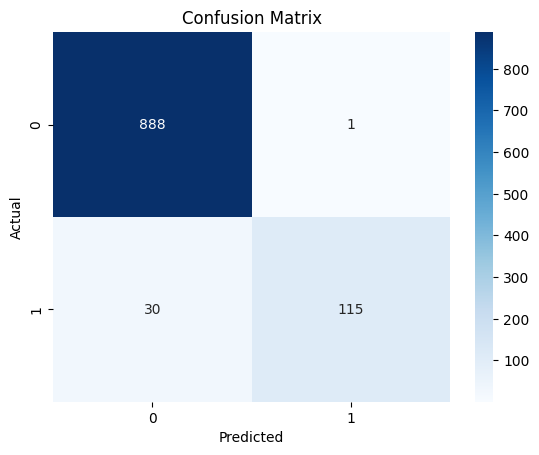

In [40]:
#visualization of classification report

cm = confusion_matrix( y_test,y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

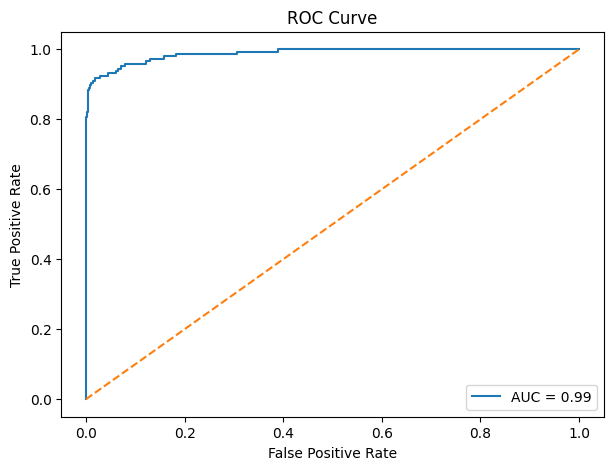

In [41]:
#AUC-ROC Curve

y_prob = model.predict_proba(X_test_tfidf)[:,1]

fpr,tpr,thresholds = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [42]:
#Testing with custom messsage
def predict_sms(text):
    text=clean_text(text)
    vector=tfidf.transform([text])
    prediction=model.predict(vector)
    if prediction[0]==1:
        return "Spam"
    else:
        return "Ham"

In [43]:
predict_sms(
"Congratulations! You won a free iPhone. Click now!"
)

'Spam'